In [1]:
library(Seurat)
library(CellChat)
library(ggplot2)
library(ggraph)
library(dplyr)
library(tidyverse) 
library(reshape2) # dcast
library(ggh4x)
source('plotDesign.r')
source('FNC.r')
sfile <- function(filename, folder="output") FNC(folder, filename, pfx="Figure4", sep="_", pfxDate = FALSE)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following object is masked from ‘package:Seurat’:

    components


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: ggplot2


Attaching package: ‘ggraph’


The following object is masked from ‘package:sp’:

    geometry


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 

In [2]:
# load seuratObj coi
seu <- readRDS("output/1_annot_coi_seu.rds")
# load annotation
annotation <- readRDS("output/1_annot_coi_annotation.rds")

In [4]:
table(seu@meta.data$orig.ident)


    A05     A07     A08     A09     A10     A11     A12     A13     A14     A15 
    281     454     754     798     433    3163     320    3352    2345    2740 
NUC0008 NUC010A NUC015A NUC0240 NUC0691 NUC0786 
   4982    1149    2536    5191    4260    4855 

# Cellchat utility

In [3]:
# setup cellchat Database
cytos <- c("TNF", "IL7", "IFNG", "FASLG")

CellChatDB.use <- subsetDB(CellChatDB.human, 
                           search = cytos, 
                           key = c("ligand.symbol"))

IL15_IL15RA_IL2RG_IL2RB <- c(pathway_name = "IL2", 
  interaction_name = "IL15_IL15RA_IL2RG_IL2RB", 
  interaction_name_2 = "IL15 - (IL15RA+IL2RG+IL2RB)",
  ligand = "IL15",
  ligand.symbol = "IL15",
  receptor = "IL15RA_IL2RG_IL2RB",
  receptor.symbol = "IL15RA, IL2RG, IL2RB")


IL15RA_IL2RG_IL2RB <- c(pathway_name = "IL2", 
  interaction_name = "IL15RA_IL2RG_IL2RB", 
  interaction_name_2 = "IL15RA - (IL2RG+IL2RB)",
  ligand = "IL15RA",
  ligand.symbol = "IL15RA",
  receptor = "IL2RG_IL2RB",
  receptor.symbol = "IL2RG, IL2RB")

IL15RA_IL15_IL2RG_IL2RB <- c(pathway_name = "IL2",
interaction_name = "IL15RA_IL15_IL2RG_IL2RB",
interaction_name_2 = "(IL15RA+IL15) - (IL2RG+IL2RB)",
ligand = "IL15RA_IL15",
ligand.symbol = "IL15RA, IL15",
receptor = "IL2RG_IL2RB",
receptor.symbol = "IL2RG, IL2RB")

ia.IL15add <- data.frame(matrix(NA, nrow=1, ncol=ncol(CellChatDB.use$interaction), 
                             dimnames = list(c("IL15RA_IL2RG_IL2RB"), #, "IL15RA_IL15_IL2RG_IL2RB"),
                                             colnames(CellChatDB.use$interaction))
                             )
                      )

#ia.IL15add["IL15RA_IL2RG_IL2RB", names(IL15RA_IL2RG_IL2RB)] <- IL15RA_IL2RG_IL2RB
ia.IL15add["IL15RA_IL15_IL2RG_IL2RB", names(IL15RA_IL15_IL2RG_IL2RB)] <- IL15RA_IL15_IL2RG_IL2RB
ia.IL15add["IL15_IL15RA_IL2RG_IL2RB", names(IL15_IL15RA_IL2RG_IL2RB)] <- IL15_IL15RA_IL2RG_IL2RB

# Add Complex Entry
complex.IL15add <- data.frame(
                        subunit_1 = c("IL15RA", "IL2RG", "IL15RA"), 
                        subunit_2 = c("IL2RB", "IL2RB", "IL15"), 
                        subunit_3 = c("IL2RG", "", ""), 
                        subunit_4 =  c("", "", ""), 
                        subunit_5 =  c("", "", ""), row.names = c("IL15RA_IL2RG_IL2RB", "IL2RG_IL2RB", "IL15RA_IL15"))

CellChatDB.use$interaction <- rbind(CellChatDB.use$interaction, ia.IL15add )
CellChatDB.use$complex <- rbind(CellChatDB.use$complex, complex.IL15add)

In [28]:
#' Perform CellChat Analysis Pipeline
#'
#' @param ccDB A CellChat database object. 
#' @param obj A Seurat object 
#' @param tt (trim threshold) float value  passed to "computeCommProb" method
#' @param cluster_col Metadata column in the Seurat object that contains cluster annotations.
#' @param assay Assay to use for the analysis. Default is "RNA".
#'
#' @return A data frame of significant intercellular communication interactions with probabilities exceeding a defined threshold.
#'

cellchat_analysis_pip <- function(ccDB, obj, cluster_col, tt = 0.01, assay = "RNA", return_cc = FALSE){
    
    cellchat <- createCellChat(object = obj, group.by = "interactome_annotation", assay = "RNA")
    # We want to include all selected ligand -> no DE, no threshold for filtering
    cellchat@DB <- ccDB
    cellchat <- subsetData(cellchat)
    cellchat <- identifyOverExpressedGenes(cellchat,do.fast = T, 
                                       do.DE = FALSE, thresh.p = 1, thresh.pc = 0, 
                                       thresh.fc = 0)
    cellchat <- identifyOverExpressedInteractions(cellchat)

    # Threshold trim 0.01, mainly because of Il15RA, which was expressed by only 4.7% of aa CD8 cells 
    cellchat <- computeCommunProb(cellchat, type="truncatedMean", trim = tt)
    cellchat@net$pval <- p.adjust(cellchat@net$pval)
    cellchat <- filterCommunication(cellchat, min.cells = 10)
    df_net <- subsetCommunication(cellchat, thresh = 0.05)
    
    if(return_cc)
        return(list(net = df_net, cc = cellchat))
    else
        return(df_net)

}

compare_tt <- function(tt, ccDB, obj, cluster_col, ...){  
    nets = list()
    # tt = trim treshold
    for (t in tt){
        
    tryCatch(
        expr = {
            message("Trim Treshold: ", t)
            res = cellchat_analysis_pip(ccDB = ccDB, obj =  obj, cluster_col = cluster_col, tt= t)
            res$tt = t
            nets[[paste0("tt", t)]] <- res
        }, 
        error = function(e){
            message('Caught an error!')
            print(e)
        },
        finally = {
            next
        })
    }

    net_df <- do.call("rbind", nets)
    net_df$annot = paste0(net_df$source, "_", net_df$target, "+++", net_df$interaction_name)
    net_d <- dcast(net_df, formula = annot ~ tt, value.var="prob")
    return(net_d)
    
    
    
    
}

getOrder <- function(.data, formula, value.var){
        hobj <- dcast(data= .data, formula = formula, value.var=value.var) %>% replace(is.na(.), 100) %>%
        column_to_rownames(var = formula[[2]] %>% as.character) %>%      
        dist %>% hclust 
        return(hobj$labels[hobj$order])
}

plot_heatmap <- function(net, y_order = NULL){
    library(ggh4x)#
    #colors$palette$DarkBlue_Red$ggfill <- function(midpoint = 0)  scale_fill_gradient2(low = "#3F517C", 
    #                                                                                 high = "#EB5D12", 
    #                                                                                 mid = "grey90", 
	#																			   midpoint = midpoint)
    if(is.null(y_order))
       order <- net$interaction_name_2 %>% .[!duplicated(.)]
    else 
       order <- y_order
    p <- net %>%
    group_by(interaction_name) %>%
    mutate(st = paste0(source, " > ", target), 
           ia_scaled = scale(prob),
           prob_plot = -1/log(prob)) %>%  # z scale values by rows) 
    mutate(ia_ordered = factor(interaction_name_2, 
                         levels = order)#ifelse(is.null(y_order), 
                                  #       getOrder(., formula = interaction_name_2 ~ st, value.var = "ia_scaled"),
                                  #       y_order))
           ) %>%

    ggplot(aes(y=ia_ordered, x=interaction(target, source, sep="///"), fill=prob)) +
    #geom_tile(color="black", width=0.9, height=0.8) +
    geom_tile() +
    scale_x_discrete(guide = guide_axis_nested(delim = "&")) +  
    colors$palette$DarkBlue_Red$ggfill() +  
    labs(x="", y="") + 
    theme_paper(aspect.ratio = 1/1.5) + 
    theme(axis.text.x=element_text(angle=90, hjust=1, vjust=0.5)) 


    return(p)
}

plot_network <- function(net){

    df.simple <- net %>% group_by(source,target) %>% 
    summarise(ligs = paste0(ligand, collapse = ","), prob_sum = sum(prob))

    v_colors = RColorBrewer::brewer.pal(n = 4, name="Set1")

    g <- graph_from_data_frame(df.simple, directed = T)
    E(g)$ligand = df.simple$ligs
    E(g)$source = df.simple$source
    E(g)$weight = E(g)$weights = df.simple$prob_sum
    names(v_colors) <- V(g)$name
    V(g)$color = v_colors[V(g)$name]


    p <- ggraph(g, layout="fr") +
    geom_edge_fan(arrow=arrow(type="closed", length = unit(0.3, "cm")), linemitre = 1, alpha=0.8,
              aes(color = source, width=weight, label=ligand)) +
    scale_edge_width(range = c(0.5, 2.5))+
    scale_edge_color_manual(values = v_colors) + 
    #geom_node_point(size=12, color=v_colors) +
    geom_node_label(aes(label=name), fill=V(g)$color) +
    theme_paper("blank") + theme_void()

    return(p)
}


# Analysis all data

In [5]:
seu@meta.data$interactome_annotation = NA
seu@meta.data[names(annotation), "interactome_annotation"] <- annotation
seu@meta.data$samples <- seu@meta.data$orig.ident

In [7]:
y_order <- rev(c(
             "TNF - TNFRSF1A", 
             "TNF - TNFRSF1B", 
             "IFNG - (IFNGR1+IFNGR2)",
             "FASL - FAS", 
             "IL7 - (IL7R+IL2RG)", 
             "IL18 - (IL18R1+IL18RAP)", 
             "IL15 - (IL15RA+IL2RB)", 
             "IL15RA - (IL2RG+IL2RB)", 
             "(IL15RA+IL15) - (IL2RG+IL2RB)",
             "IL15 - (IL15RA+IL2RG+IL2RB)"))

#CellChatDB.use$interaction$interaction_name_2 <- factor(CellChatDB.use$interaction$interaction_name_2 , levels = y_order)

In [10]:
str_split_i(y_order, " - ", i=2)

[1] "(IL15RA+IL2RG+IL2RB)" "(IL2RG+IL2RB)"        "(IL2RG+IL2RB)"       
 [4] "(IL15RA+IL2RB)"       "(IL18R1+IL18RAP)"     "(IL7R+IL2RG)"        
 [7] "FAS"                  "(IFNGR1+IFNGR2)"      "TNFRSF1B"            
[10] "TNFRSF1A"

In [29]:
net <- cellchat_analysis_pip(CellChatDB.use, seu, interactome_annotation, tt= 0.05)

[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 


Warning message in createCellChat(object = obj, group.by = "interactome_annotation", :
“The 'meta$samples' is not a factor. We now force it as a factor! 
”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  aa-like CD8, CD4_TRM1, Hepatocytes, Macrophages/DC 
The number of highly variable ligand-receptor pairs used for signaling inference is 7 
truncatedMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2025-11-18 10:52:41.313704]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2025-11-18 10:52:44.216638]"


In [9]:
cc <- aggregateNet(cc$cc)

In [30]:
df.simple <- net %>% group_by(source,target) %>% 
    summarise(ligs = paste0(ligand, collapse = ","), prob_sum = sum(prob))

`summarise()` has grouped output by 'source'. You can override using the
`.groups` argument.


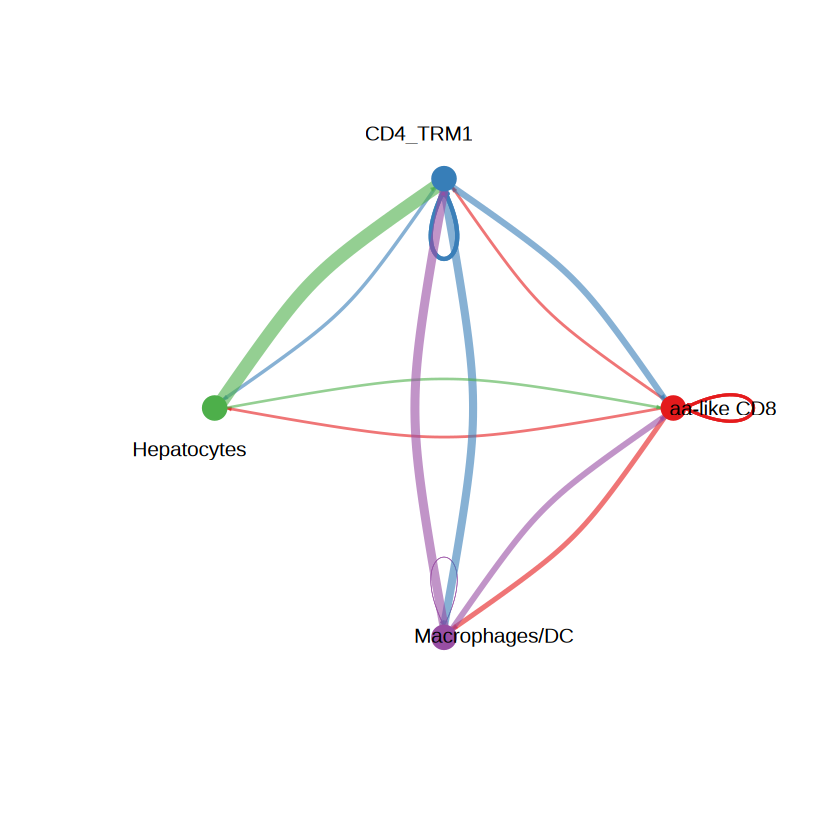

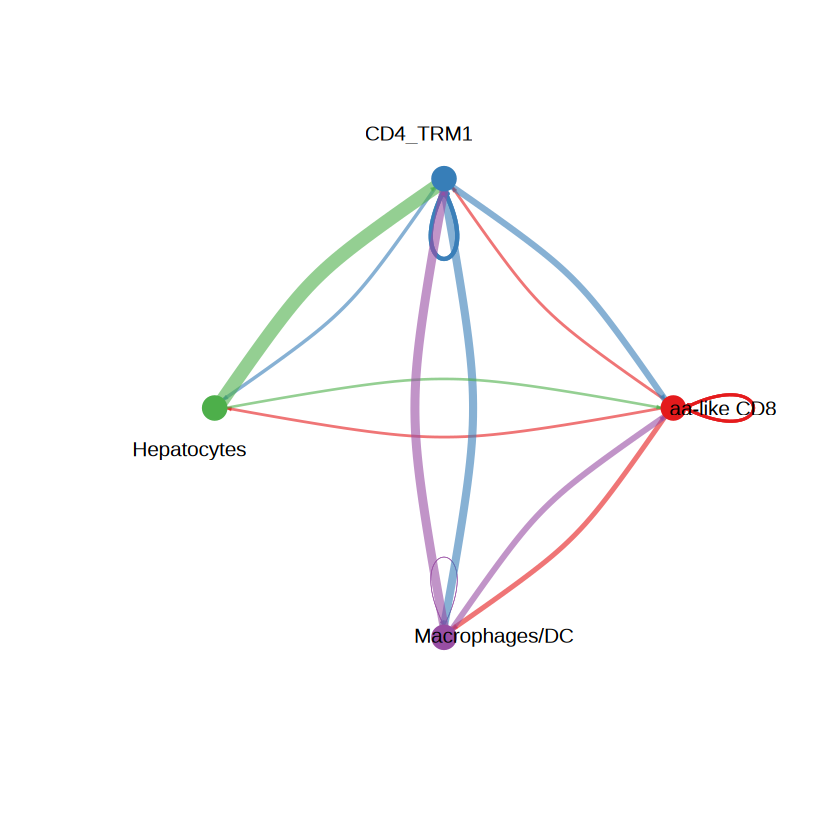

In [14]:
netVisual_circle(cc@net$weight,  weight.scale = T,  title.name = "Interaction weights/strength")

Warning message in FNC(folder, filename, pfx = "Figure4", sep = "_", pfxDate = FALSE):
“'output/Figure4_SNS_SCS_Heatmap_CommunicationProbability.pdf' 
 File already exists! Replacing it. 
 Set replace=FALSE to avoid replacing”
Warning message in FNC(folder, filename, pfx = "Figure4", sep = "_", pfxDate = FALSE):
“'output/Figure4_SNS_SCS_Heatmap_CommunicationProbability.csv' 
 File already exists! Replacing it. 
 Set replace=FALSE to avoid replacing”
Warning message in FNC(folder, filename, pfx = "Figure4", sep = "_", pfxDate = FALSE):
“'output/Figure4_SNS_SCS_img_Heatmap_CommunicationProbability.RDS' 
 File already exists! Replacing it. 
 Set replace=FALSE to avoid replacing”


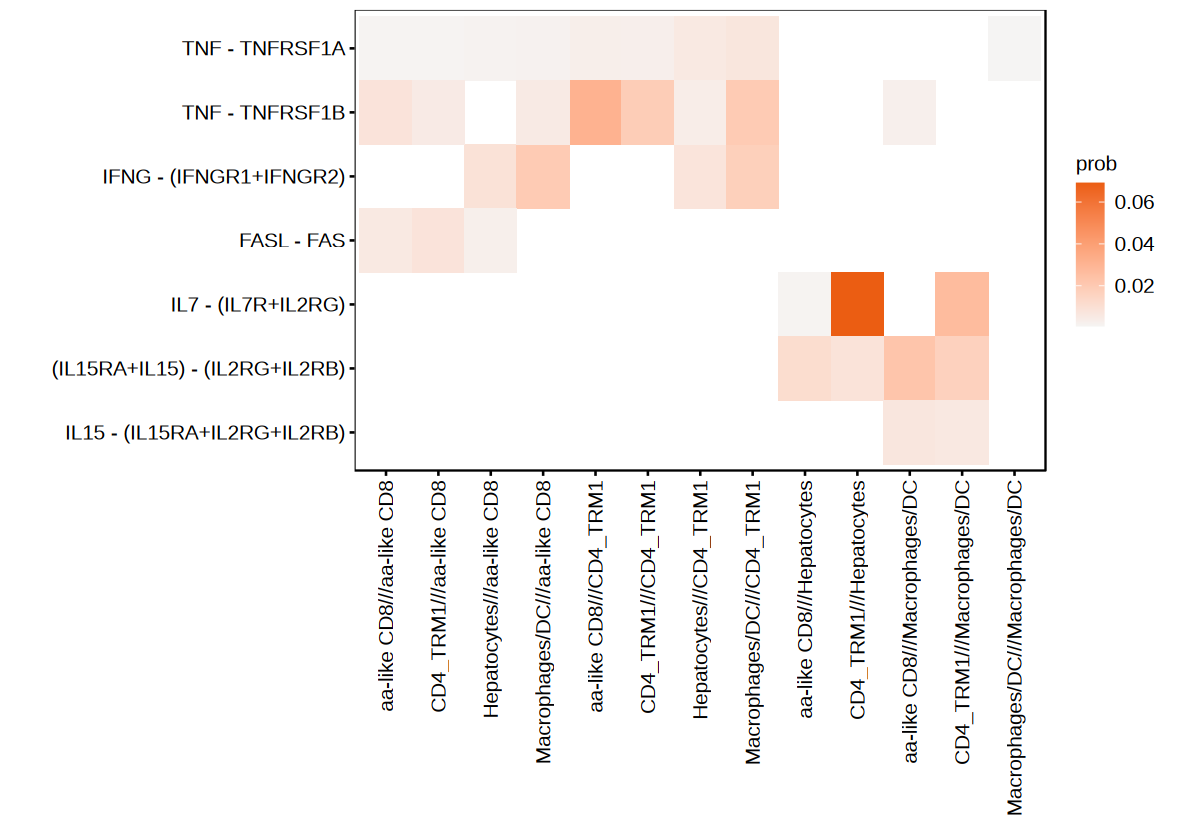

In [31]:
options(repr.plot.width=10, repr.plot.height=7)
p_heat <- plot_heatmap(net, y_order) 
p_heat
ggsave(sfile("SNS_SCS_Heatmap_CommunicationProbability.pdf"), width=10, height=10)
write.csv(p_heat$data, sfile("SNS_SCS_Heatmap_CommunicationProbability.csv"))
saveRDS(p_heat, sfile("SNS_SCS_img_Heatmap_CommunicationProbability.RDS"))

`summarise()` has grouped output by 'source'. You can override using the
`.groups` argument.


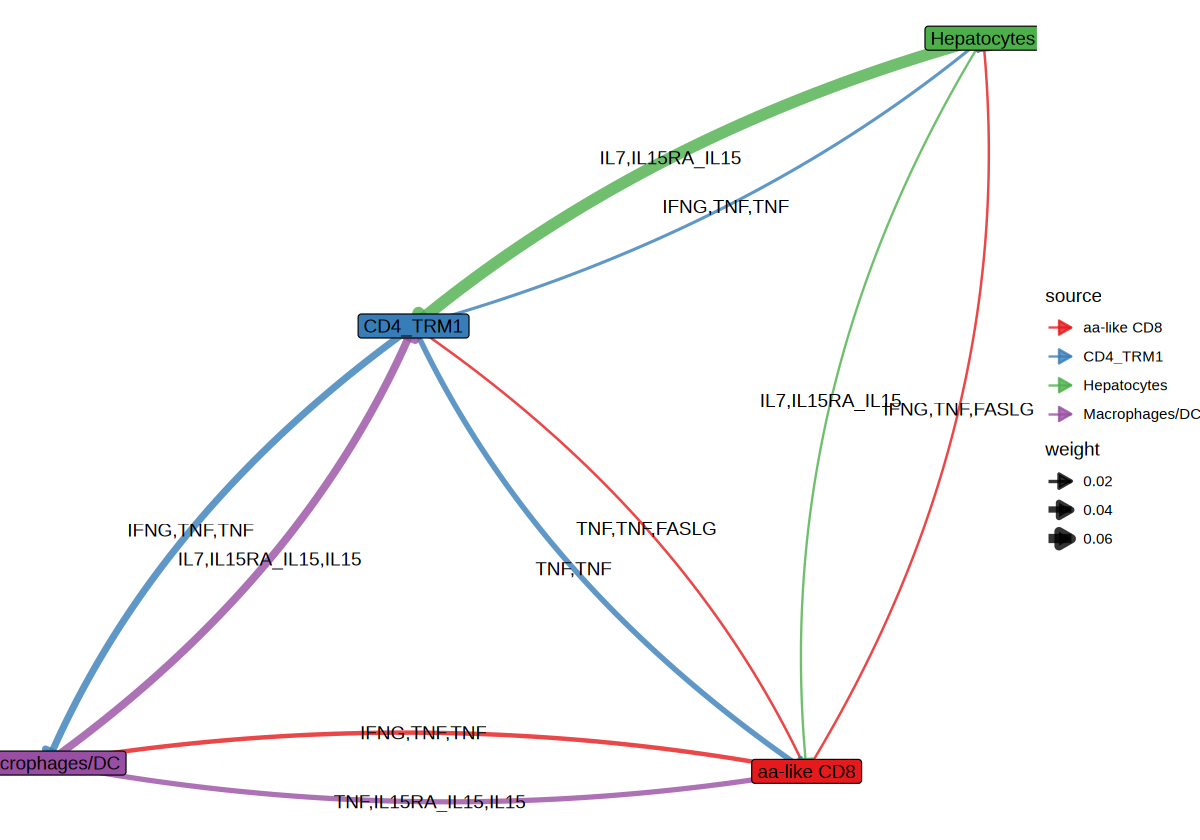

In [16]:
p_net <- plot_network(net)
p_net

ggsave(sfile("SNS_SCS_Network_Communication.pdf"), width=5, height=5)
write.csv(p_net$data, sfile("SNS_SCS_Network_Communication.csv"))
saveRDS(p_net, sfile("SNS_SCS_img_Network_Communication.RDS"))

# Analysis SCS

In [17]:
seu_SCS = subset(seu, protocol == "SCS")

[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  aa-like CD8, CD4_TRM1, Hepatocytes, Macrophages/DC 
The number of highly variable ligand-receptor pairs used for signaling inference is 7 
truncatedMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2025-11-16 19:45:28.031165]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2025-11-16 19:45:29.720611]"


Saving 7 x 7 in image
`summarise()` has grouped output by 'source'. You can override using the
`.groups` argument.


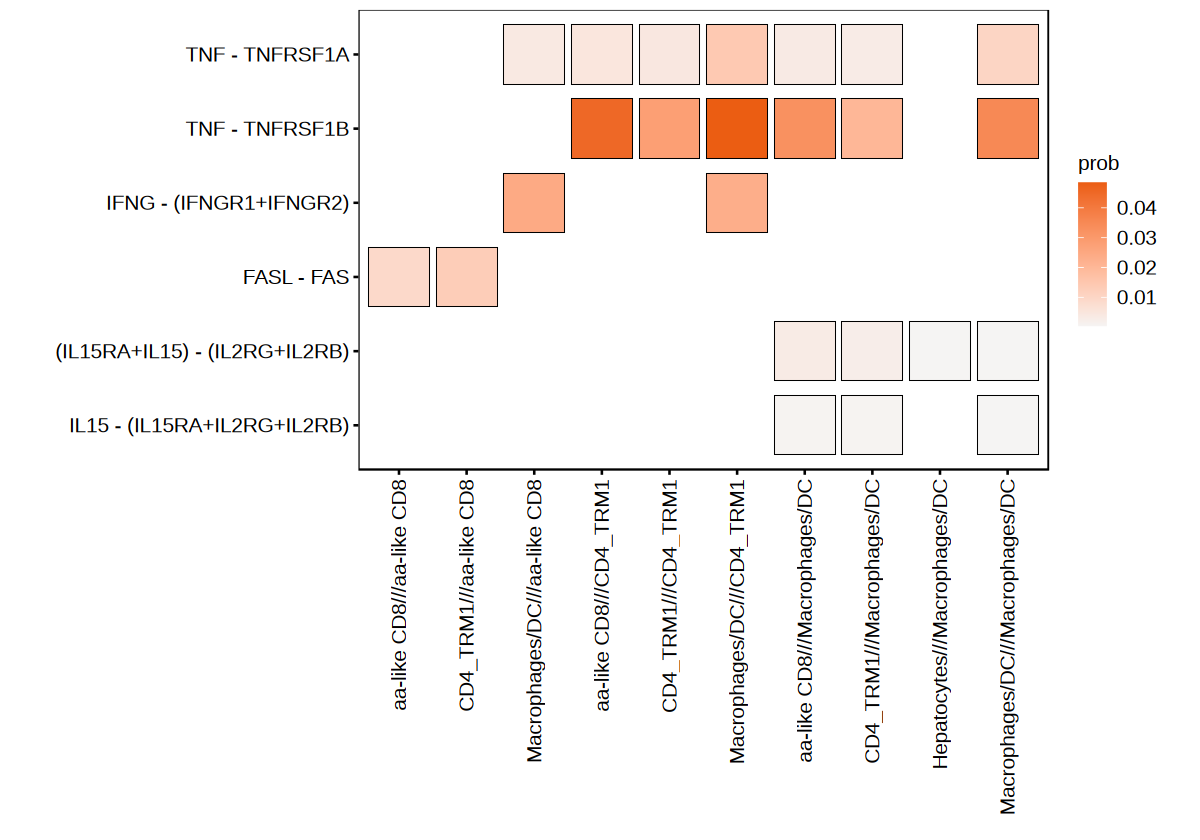

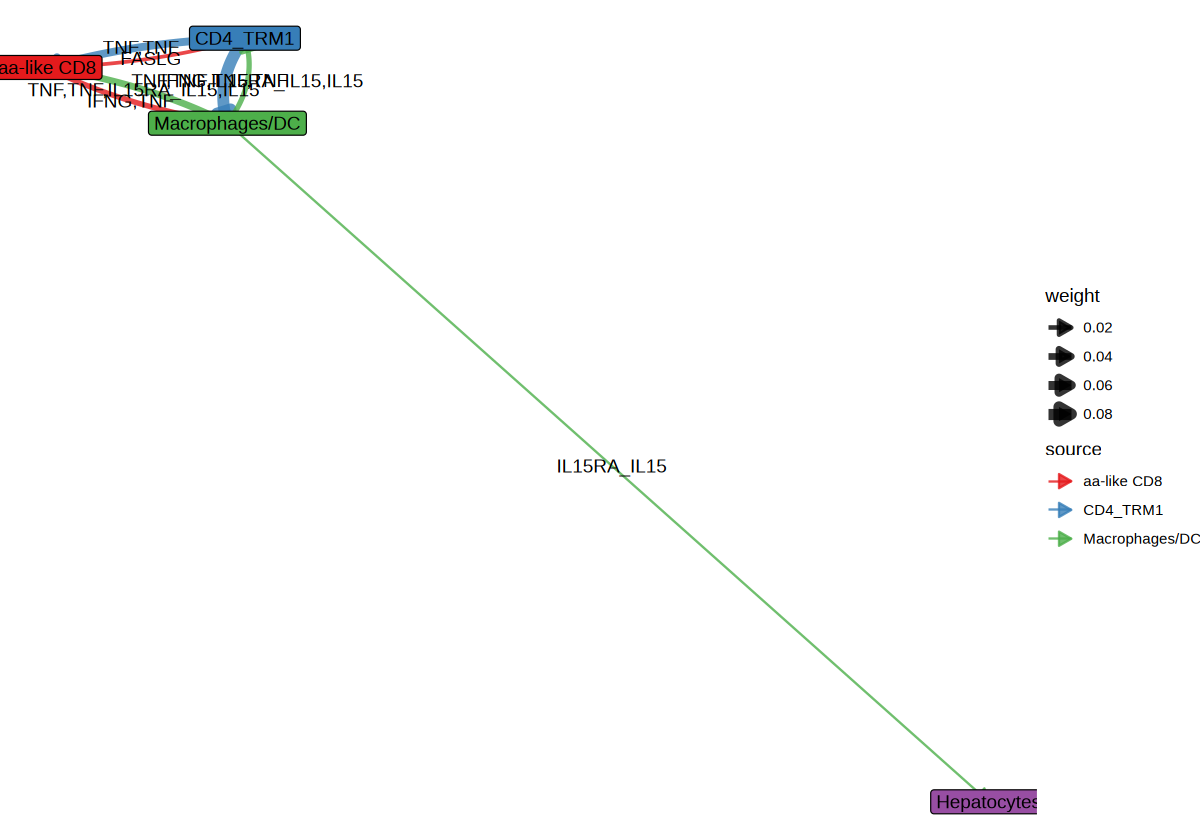

In [18]:
net <- cellchat_analysis_pip(CellChatDB.use, seu_SCS, interactome_annotation, tt= 0.05)
p_heat <- plot_heatmap(net, y_order)
p_heat
ggsave(sfile("SCS_Heatmap_CommunicationProbability.pdf"))
write.csv(p_heat$data, sfile("SCS_Heatmap_CommunicationProbability.csv"))
saveRDS(p_heat, sfile("SCS_img_Heatmap_CommunicationProbability.RDS"))

p_net <- plot_network(net)
p_net

ggsave(sfile("SCS_Network_Communication.pdf"), width=5, height=5)
write.csv(p_net$data, sfile("SCS_Network_Communication.csv"))
saveRDS(p_net, sfile("SCS_img_Network_Communication.RDS"))

# Analysis SNS 

In [19]:
seu_SNS = subset(seu, protocol == "SNS")

[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  aa-like CD8, CD4_TRM1, Hepatocytes, Macrophages/DC 
The number of highly variable ligand-receptor pairs used for signaling inference is 7 
truncatedMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2025-11-16 19:45:33.251456]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2025-11-16 19:45:35.167099]"


Saving 7 x 7 in image
`summarise()` has grouped output by 'source'. You can override using the
`.groups` argument.


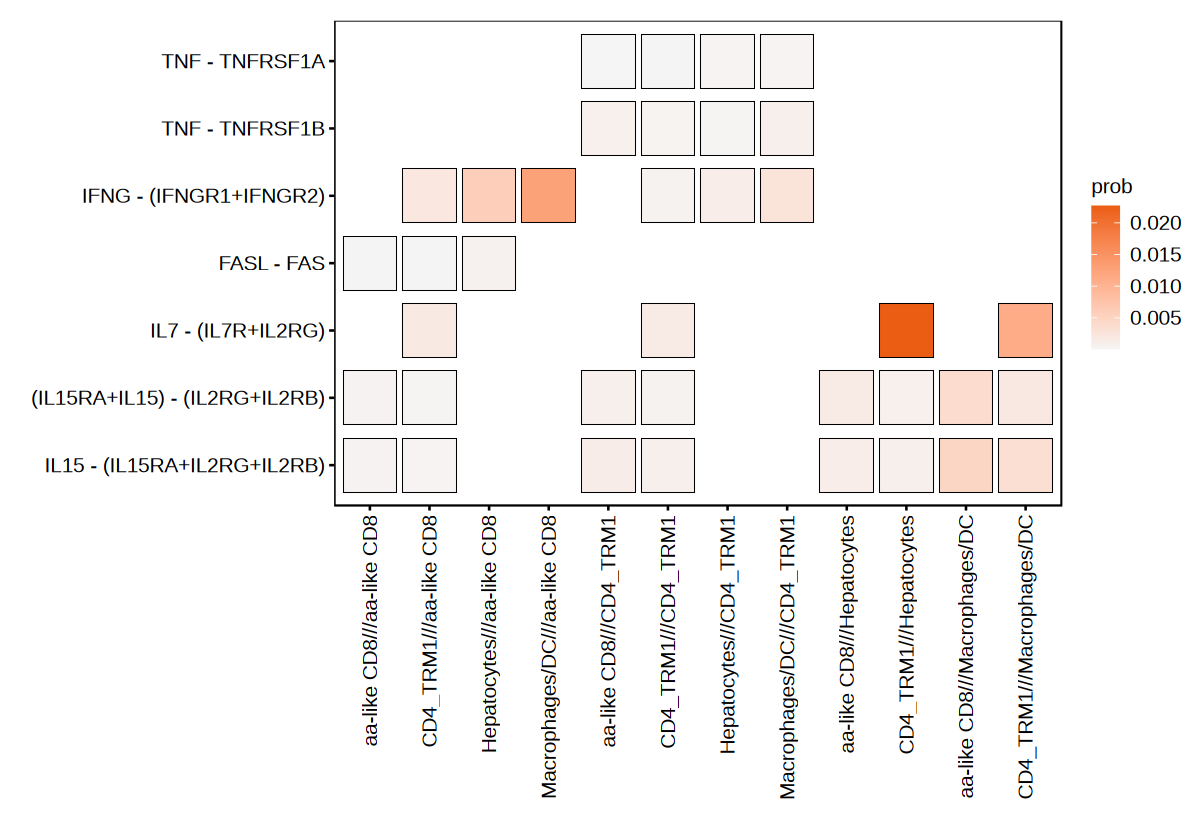

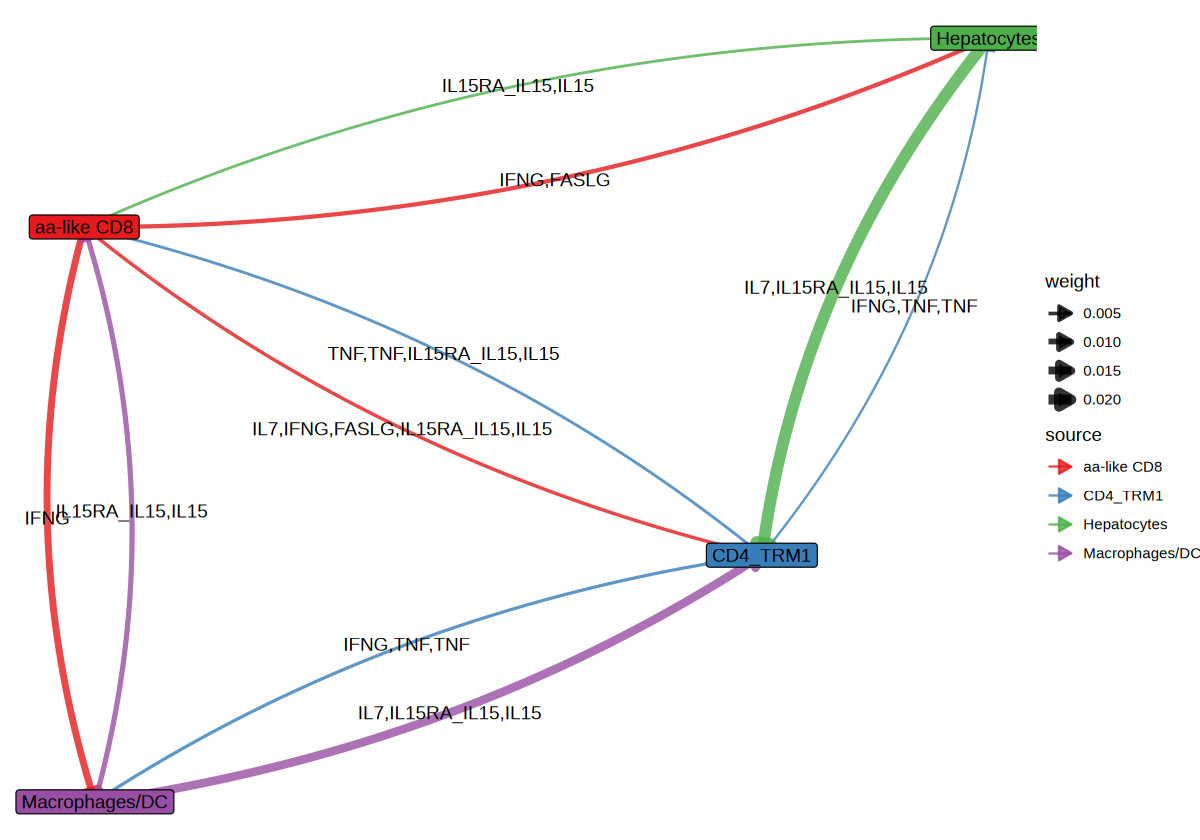

In [20]:
net <- cellchat_analysis_pip(CellChatDB.use, seu_SNS, interactome_annotation, tt= 0.05)
p_heat <- plot_heatmap(net, y_order)
p_heat
ggsave(sfile("SNS_Heatmap_CommunicationProbability.pdf"))
write.csv(p_heat$data, sfile("SNS_Heatmap_CommunicationProbability.csv"))
saveRDS(p_heat, sfile("SNS_img_Heatmap_CommunicationProbability.RDS"))

p_net <- plot_network(net)
p_net

ggsave(sfile("SNS_Network_Communication.pdf"), width=5, height=5)
write.csv(p_net$data, sfile("SNS_Network_Communication.csv"))
saveRDS(p_net, sfile("SNS_img_Network_Communication.RDS"))

# comparison

In [21]:
net_SCS <- cellchat_analysis_pip(CellChatDB.use, seu_SCS, interactome_annotation, tt = 0.05, return_cc = T)
net_SNS <- cellchat_analysis_pip(CellChatDB.use, seu_SNS, interactome_annotation, tt = 0.05, return_cc = T)

[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  aa-like CD8, CD4_TRM1, Hepatocytes, Macrophages/DC 
The number of highly variable ligand-receptor pairs used for signaling inference is 7 
truncatedMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2025-11-16 19:45:36.52019]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2025-11-16 19:45:37.770196]"
[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  aa-like CD8, CD4_TRM1, Hepatocytes, Macrophages/DC 
The number of highly variable ligand-receptor pairs used for signaling 

In [22]:
net_SNS$net$org = "SNS"
net_SCS$net$org = "SCS"
net_whole = rbind(net_SNS$net, net_SCS$net)
net_whole$annot = paste0(net_whole$source, "_", net_whole$target, "_", net_whole$interaction_name)

In [23]:
net_d <- dcast(net_whole, formula = annot ~ org, value.var="prob")
net_d[is.na(net_d)] <- 0
net_m <- melt(net_d, id.vars = c("annot"))

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


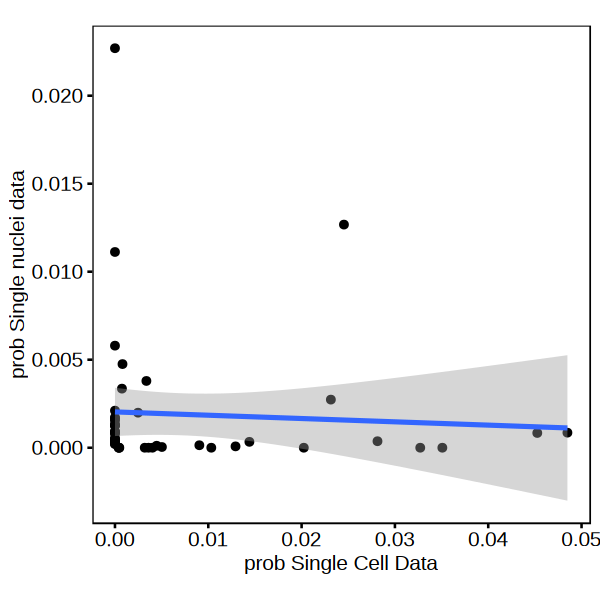

In [24]:
options(repr.plot.width=5, repr.plot.height=5)
ggplot(net_d, aes(SCS, SNS)) + geom_point() + geom_smooth(method = lm) + theme_paper() + labs(x="prob Single Cell Data", y="prob Single nuclei data")

ggsave(sfile("SNS_SCS_correlation.pdf"), width=5, height=5)

In [25]:
net_d <- compare_tt(tt = c(0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5), ccDB = CellChatDB.use, obj = seu, cluster_col = interactome_annotation)

Trim Treshold: 0



[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  aa-like CD8, CD4_TRM1, Hepatocytes, Macrophages/DC 
The number of highly variable ligand-receptor pairs used for signaling inference is 7 
truncatedMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2025-11-16 19:45:41.910599]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2025-11-16 19:45:44.237369]"


Trim Treshold: 0.01



[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  aa-like CD8, CD4_TRM1, Hepatocytes, Macrophages/DC 
The number of highly variable ligand-receptor pairs used for signaling inference is 7 
truncatedMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2025-11-16 19:45:45.150831]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2025-11-16 19:45:47.820627]"


Trim Treshold: 0.05



...

[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  aa-like CD8, CD4_TRM1, Hepatocytes, Macrophages/DC 
The number of highly variable ligand-receptor pairs used for signaling inference is 7 
truncatedMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2025-11-16 19:46:15.751967]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2025-11-16 19:46:17.902614]"


Trim Treshold: 0.5



[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  aa-like CD8, CD4_TRM1, Hepatocytes, Macrophages/DC 
The number of highly variable ligand-receptor pairs used for signaling inference is 7 
truncatedMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2025-11-16 19:46:18.845649]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2025-11-16 19:46:20.834433]"


Caught an error!



<simpleError in subsetCommunication_internal(net, LR, cells.level, slot.name = slot.name,     sources.use = sources.use, targets.use = targets.use, signaling = signaling,     pairLR.use = pairLR.use, thresh = thresh, datasets = datasets,     ligand.pvalues = ligand.pvalues, ligand.logFC = ligand.logFC,     ligand.pct.1 = ligand.pct.1, ligand.pct.2 = ligand.pct.2,     receptor.pvalues = receptor.pvalues, receptor.logFC = receptor.logFC,     receptor.pct.1 = receptor.pct.1, receptor.pct.2 = receptor.pct.2): No significant signaling interactions are inferred based on the input!>


Using annot as id variables



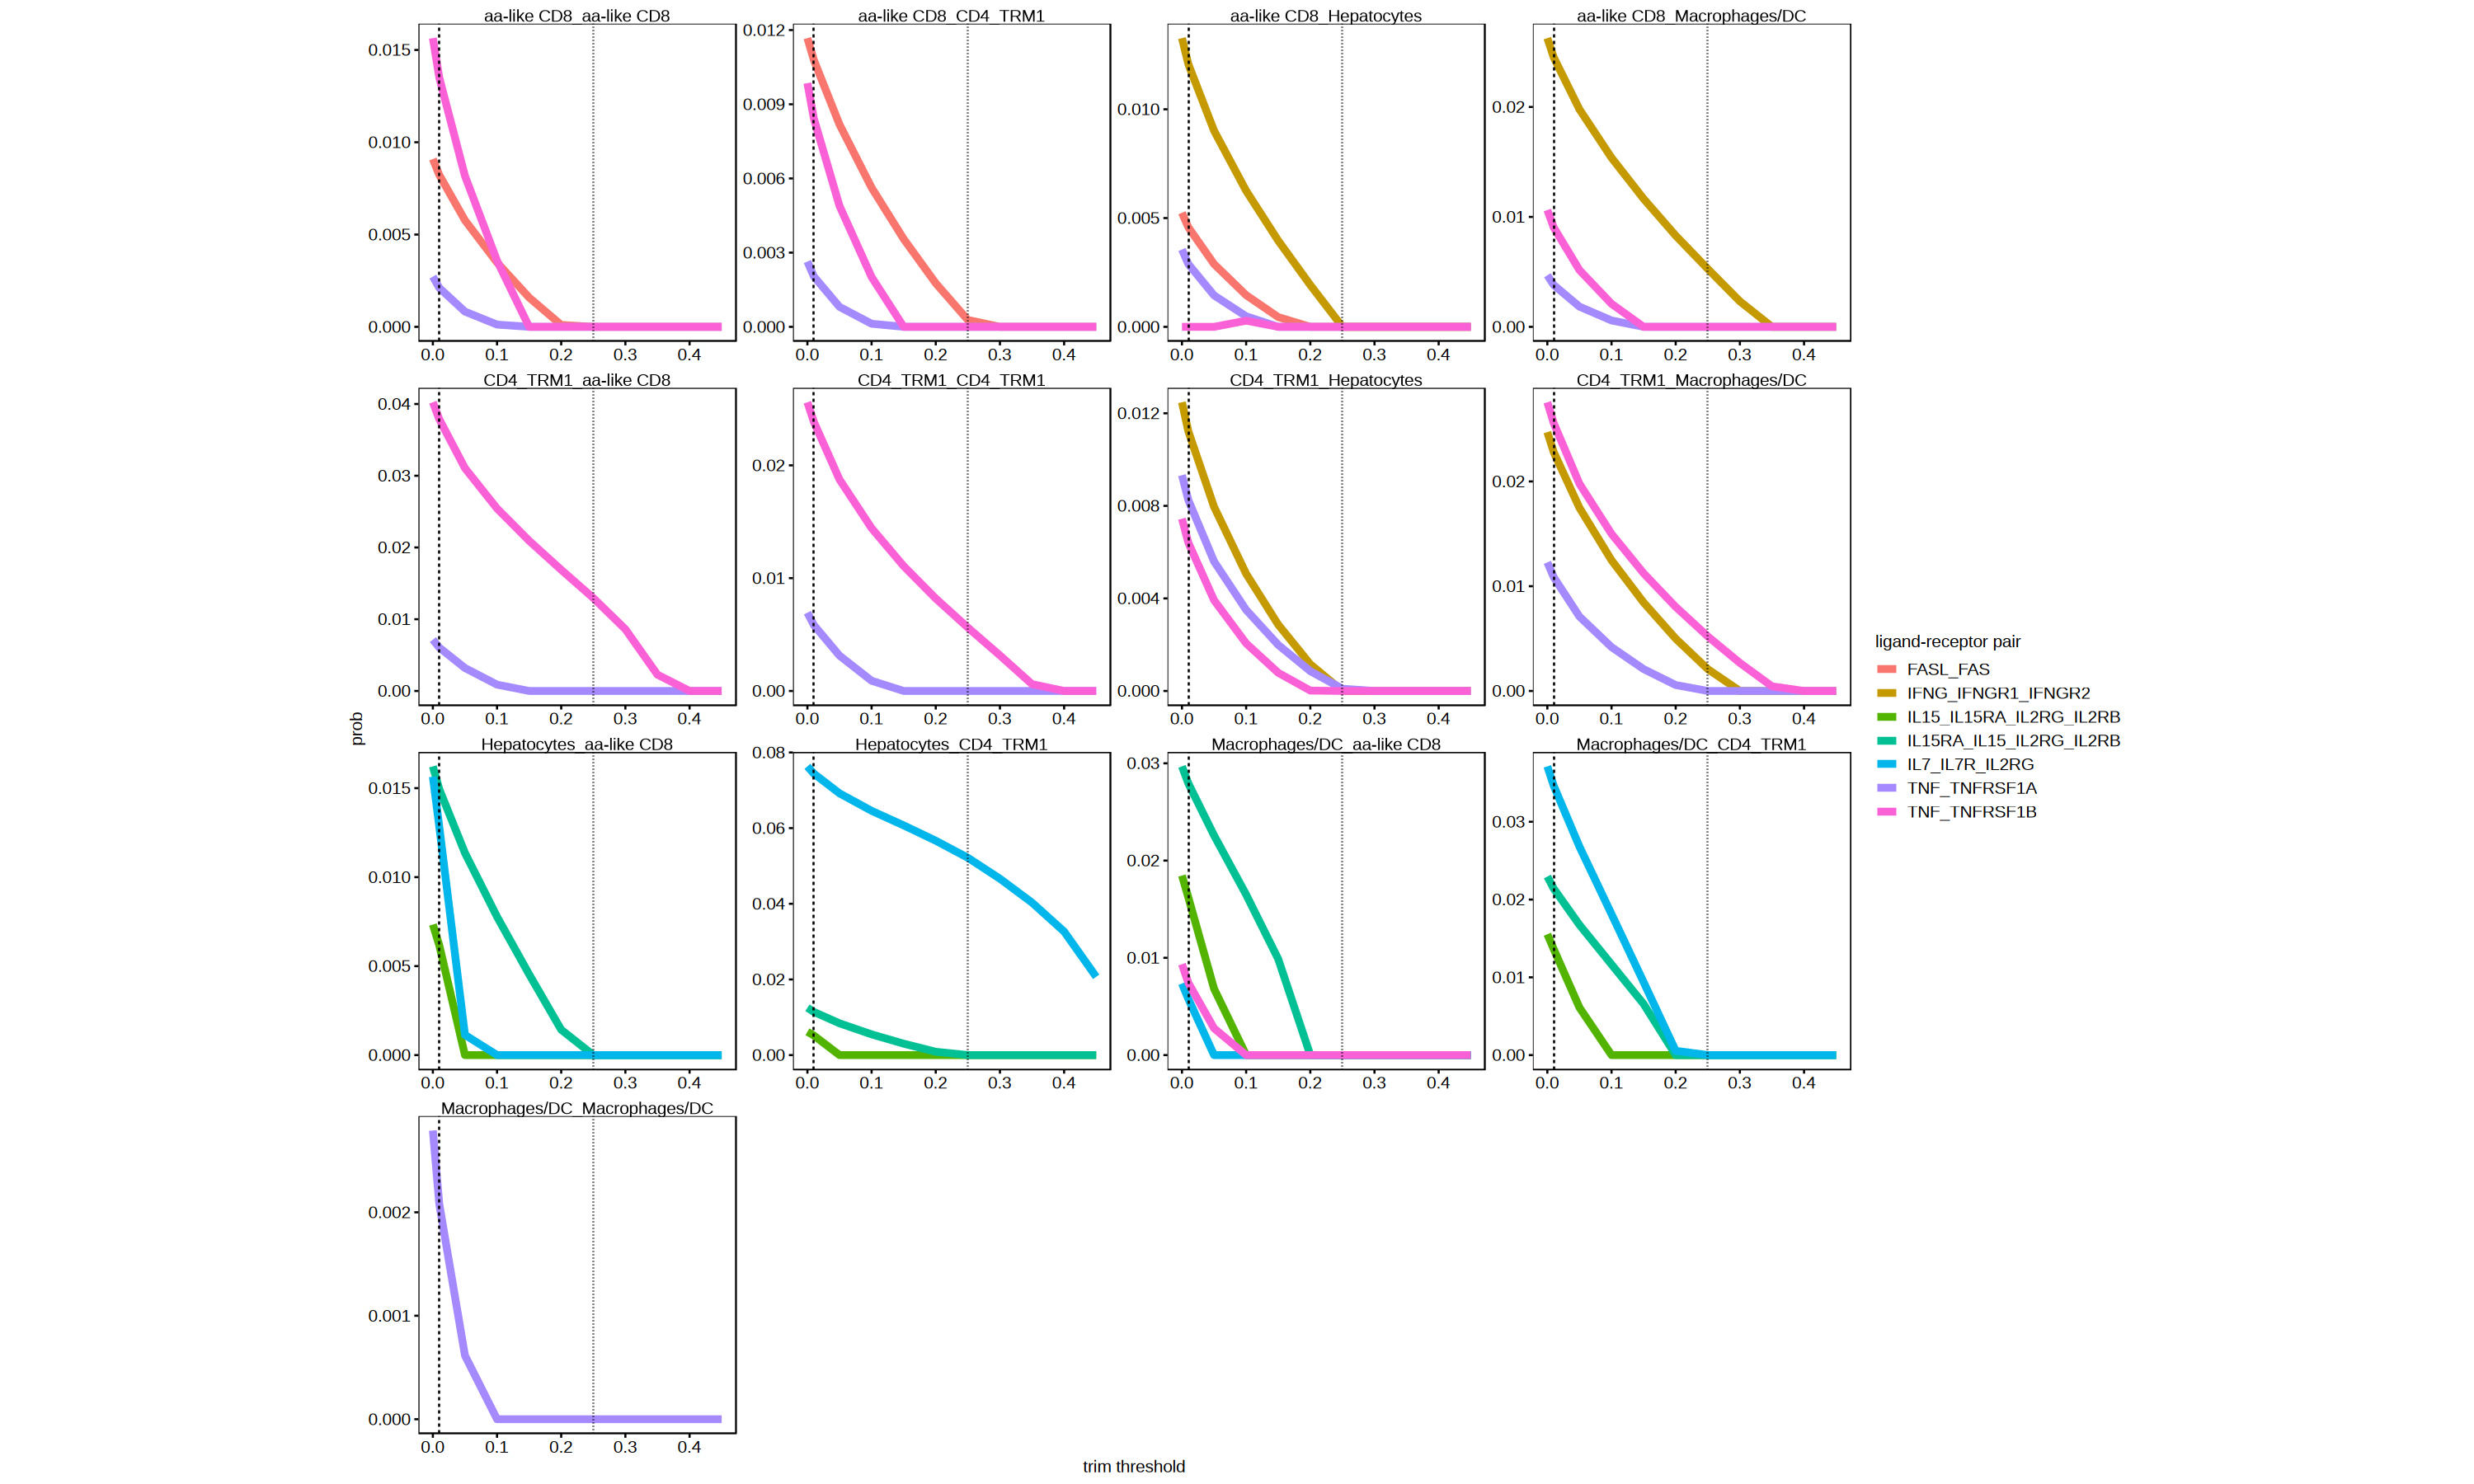

In [26]:
net_m <- melt(net_d)
net_m[is.na(net_m)] <- 0
net_m$variable <- as.numeric(as.character( net_m$variable))
net_m$cluster = str_split_i(net_m$annot, pattern = "\\+\\+\\+", i = 1)
net_m$ligand = str_split_i(net_m$annot, pattern = "\\+\\+\\+", i = 2)
options(repr.plot.width=25, repr.plot.height=15)
ggplot(net_m, aes(x=variable, y=value, color=ligand)) + geom_line(size=2) + facet_wrap(~cluster, scales = "free") + theme_paper() + labs(x="trim threshold", y="prob", color="ligand-receptor pair") + 
geom_vline(xintercept = 0.01, linetype="dashed") +
geom_vline(xintercept = 0.25, linetype="dotted")

ggsave(sfile("tt_cutoff.pdf"), width=25, height=15)
write.csv(p_heat$data, sfile("tt_cutoff.csv"))
saveRDS(p_heat, sfile("tt_cutoff.RDS"))

# Session

In [27]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.3 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/envs/r-scrna/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggh4x_0.3.1         reshape2_1.4.4      lubridate_1.9.4    
 [4] forcats_1.0.0       stringr_1.6.0       purrr_1.2.0        
 [7] readr_2.1.5         tidyr_1.3.1         tibble_3.3.0       
[10] tidyverse_2.0.0     ggraph_2.2.1        CellChat_2.2.0     
[13] Biobase_2.62.0      BiocGenerics_0.